In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "survey-data"

# Introduction
The discovery of handwashing had a profound affect on the world of medicine and changed life expectancy forever, all thanks to Dr. Ignaz Semmelweis. In 1847 Semmelweis discovers handwashing, and that contaminated hands were a major cause of childbed fever and by enforcing handwashing at his hospital he saved hundreds of lives, and it makes for a perfect data analysis project. 

## Context
I'll be taking the code used for [Data Camp's Dr. Semmelweis Handwashing Analysis](https://app.datacamp.com/learn/projects/1991) project and applying it here with some additional steps taken for added insights. 

## Data Sources 
I'll be using two dataframes associated with the Semmelweis Survey data sourced from Data Camp's website, which can be found [here](https://app.datacamp.com/learn/projects/1991), with this [license](https://www.divvybikes.com/data-license-agreement).

## Objective
I'm setting this analysis against a fictional business objective set by the hospital administration at Modern Health Medical Center is preparing for their upcoming annual Hand Hygiene Awareness Week. 

The event aims to educate staff, patients, and visitors on the critical importance of handwashing to prevent infections and improve patient safety. 

As the data analyst, I will be analyzing historical data on handwashing compliance and its impact on health outcomes before and after its discovery, with the overall goal of supporting the development of targeted campaigns and training programs to ensure consistent hand hygiene practices across the hospital.

## Cleaning & EDA Documentation
This dataset has already gone through cleaning prior to being available through Data Camp, so no cleaning will be necessary. 

# Exploration

### High Level Review

I'll begin by getting the base summary of each field within a 10 year period between , giving us 2 1/2 years worth of data to review the effect of Semmelweis' discovery. 

In [2]:
library(tidyverse)
library(lubridate)
library(scales)

# Load in the datasets, monthly_deaths, and yearly_deaths_by_clinic

yearly_deaths <- read_csv("/kaggle/input/survey-data/yearly_deaths_by_clinic.csv")
monthly_deaths <- read_csv("/kaggle/input/survey-data/monthly_deaths.csv")

head(yearly_deaths)
head(monthly_deaths)

str(yearly_deaths)
str(monthly_deaths)

unique(yearly_deaths$year)
unique(monthly_deaths$date)


Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




Rows: 12 Columns: 4


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): clinic
dbl (3): year, births, deaths


...

date,births,deaths
<date>,<dbl>,<dbl>
1841-01-01,254,37
1841-02-01,239,18
1841-03-01,277,12
1841-04-01,255,4
1841-05-01,255,2
1841-06-01,200,10


spc_tbl_ [12 × 4] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ year  : num [1:12] 1841 1842 1843 1844 1845 ...
 $ births: num [1:12] 3036 3287 3060 3157 3492 ...
 $ deaths: num [1:12] 237 518 274 260 241 459 86 202 164 68 ...
 $ clinic: chr [1:12] "clinic 1" "clinic 1" "clinic 1" "clinic 1" ...
 - attr(*, "spec")=
  .. cols(
  ..   year = col_double(),
  ..   births = col_double(),
  ..   deaths = col_double(),
  ..   clinic = col_character()
  .. )
 - attr(*, "problems")=<externalptr> 


spc_tbl_ [98 × 3] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ date  : Date[1:98], format: "1841-01-01" "1841-02-01" ...
 $ births: num [1:98] 254 239 277 255 255 200 190 222 213 236 ...
 $ deaths: num [1:98] 37 18 12 4 2 10 16 3 4 26 ...
 - attr(*, "spec")=
  .. cols(
  ..   date = col_date(format = ""),
  ..   births = col_double(),
  ..   deaths = col_double()
  .. )
 - attr(*, "problems")=<externalptr> 


[1] 1841 1842 1843 1844 1845 1846

[1] "1841-01-01" "1841-02-01" "1841-03-01" "1841-04-01" "1841-05-01"
 [6] "1841-06-01" "1841-07-01" "1841-08-01" "1841-09-01" "1841-10-01"
[11] "1841-11-01" "1842-01-01" "1842-02-01" "1842-03-01" "1842-04-01"
[16] "1842-05-01" "1842-06-01" "1842-07-01" "1842-08-01" "1842-09-01"
[21] "1842-10-01" "1842-11-01" "1842-12-01" "1843-01-01" "1843-02-01"
[26] "1843-03-01" "1843-04-01" "1843-05-01" "1843-06-01" "1843-07-01"
[31] "1843-08-01" "1843-09-01" "1843-10-01" "1843-11-01" "1843-12-01"
[36] "1844-01-01" "1844-02-01" "1844-03-01" "1844-04-01" "1844-05-01"
[41] "1844-06-01" "1844-07-01" "1844-08-01" "1844-09-01" "1844-10-01"
[46] "1844-11-01" "1844-12-01" "1845-01-01" "1845-02-01" "1845-03-01"
[51] "1845-04-01" "1845-05-01" "1845-06-01" "1845-07-01" "1845-08-01"
[56] "1845-09-01" "1845-10-01" "1845-11-01" "1845-12-01" "1846-01-01"
[61] "1846-02-01" "1846-03-01" "1846-04-01" "1846-05-01" "1846-06-01"
[66] "1846-07-01" "1846-08-01" "1846-09-01" "1846-10-01" "1846-11-01"
[71] "1846-12-01" "1847-01-01" "1847-02-01" "1847-03-01" "1847-04-01"
[76] "1847-05-01" "1847-06-01" "1847-07-01" "1847-08-01" "1847-09-01"
[81] "1847-10-01" "1847-11-01" "1847-12-01" "1848-01-01" "1848-02-01"
[86] "1848-03-01" "1848-04-01" "1848-05-01" "1848-06-01" "1848-07-01"
[91] "1848-08-01" "1848-09-01" "1848-10-01" "1848-11-01" "1848-12-01"
[96] "1849-01-01" "1849-02-01" "1849-03-01"

# Processing
***

So looking at the base data, there are already some things I'd like to change. 

1. We have a births and deaths field in both data frames, but I'd like to add a field to measure the percentage difference. We'll add a proportion_deaths field that gives a decimal number to indicate the ratio of birth to deaths. 
2. We have no indication of when Semmelweis's discovery of handwashing was implemented in the data so we'll need to make a field to indicate that. 
3. It'd be helpful to have the date field split into separate fields for less granular analysis, so I'll add fields for month and year to the monthly_deaths dataset. 

### 1. Adding Proportion Deaths

In [3]:
# I'll start by adding a new column titled proportion_deaths that calculates the death to birth ratio for the two dataframes. 

 yearly_deaths <- yearly_deaths %>%
	mutate(proportion_deaths = deaths / births * 100)
    
# Adjust the formatting of date column to a from character to date. 

monthly_deaths <- monthly_deaths %>%
mutate(date = as.Date(date, format = "%Y-%d-%m"))

str(monthly_deaths)

monthly_deaths <- monthly_deaths %>%
	mutate(proportion_deaths = deaths / births * 100)

head(yearly_deaths)

head(monthly_deaths) 

tibble [98 × 3] (S3: tbl_df/tbl/data.frame)
 $ date  : Date[1:98], format: "1841-01-01" "1841-02-01" ...
 $ births: num [1:98] 254 239 277 255 255 200 190 222 213 236 ...
 $ deaths: num [1:98] 37 18 12 4 2 10 16 3 4 26 ...


year,births,deaths,clinic,proportion_deaths
<dbl>,<dbl>,<dbl>,<chr>,<dbl>
1841,3036,237,clinic 1,7.806324
1842,3287,518,clinic 1,15.759051
1843,3060,274,clinic 1,8.954248
1844,3157,260,clinic 1,8.235667
1845,3492,241,clinic 1,6.901489
1846,4010,459,clinic 1,11.446384


date,births,deaths,proportion_deaths
<date>,<dbl>,<dbl>,<dbl>
1841-01-01,254,37,14.5669291
1841-02-01,239,18,7.5313808
1841-03-01,277,12,4.3321300
1841-04-01,255,4,1.5686275
1841-05-01,255,2,0.7843137
1841-06-01,200,10,5.0000000


### 2. Add the Handwashing Threshold

I'll accomplish this by setting a variable for when handwashing started, which was June 1st, 1847. Then we'll set the handwashing_started field as a boolean to indicate the start of handwashing. I'll also add it to the yearly_deaths so we can get a higher view of the impact. 

In [4]:
# Add the threshold for handwashing started vs. not started for the monthly_deaths data frame. 
handwashing_start = as.Date('1847-06-01')

# Create the field as a boolean within the monthly_deaths & yearly_deaths
monthly_deaths <- monthly_deaths %>%
  mutate(handwashing_started = ifelse(date < handwashing_start, FALSE, TRUE))

# Check the monthly data frame.

unique(monthly_deaths$handwashing_started)
str(monthly_deaths$handwashing_started)
head(monthly_deaths)
summary(monthly_deaths$handwashing_started)

[1] FALSE  TRUE

 logi [1:98] FALSE FALSE FALSE FALSE FALSE FALSE ...


date,births,deaths,proportion_deaths,handwashing_started
<date>,<dbl>,<dbl>,<dbl>,<lgl>
1841-01-01,254,37,14.5669291,FALSE
1841-02-01,239,18,7.5313808,FALSE
1841-03-01,277,12,4.3321300,FALSE
1841-04-01,255,4,1.5686275,FALSE
1841-05-01,255,2,0.7843137,FALSE
1841-06-01,200,10,5.0000000,FALSE


   Mode   FALSE    TRUE 
logical      76      22 

### 3. Adding Less Granular Date Data

Though we've gotten all the data formatted correctly, I'm also going to add fields for the month, day, and day of week. 

In [5]:
# Create the month field by parsing it from the date field.  
monthly_deaths["month"] <- format(as.Date(monthly_deaths$date), "%m")

# Check that the field was created and its values line up with the months. 
unique(monthly_deaths$month)

# Since each month is designated by numbers 1:12, I'll create a vector of the names of the months of the year. 
month_names <- c("January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December")

# Assign the integer data type to the month_numbers variable. 
month_numbers <- as.integer(format(as.Date(monthly_deaths$date), "%m"))

# Combine the names with the month numbers vectors. 
monthly_deaths$month <- month_names[month_numbers]

# Change the month column into a factor to arrange the months in logical order. 
monthly_deaths<- monthly_deaths%>%
                    mutate(month = factor(month, levels = month_names, ordered = TRUE))

# Create the year field. 
monthly_deaths <- monthly_deaths %>%
    mutate(
            year = year(date)
            )
              
# Lets arrange the data by month since this is the monthly_deaths data frame. 

monthly_deaths <- monthly_deaths %>%
    arrange(monthly_deaths, month)

head(monthly_deaths)

[1] "01" "02" "03" "04" "05" "06" "07" "08" "09" "10" "11" "12"

date,births,deaths,proportion_deaths,handwashing_started,month,year
<date>,<dbl>,<dbl>,<dbl>,<lgl>,<ord>,<dbl>
1841-01-01,254,37,14.5669291,FALSE,January,1841
1841-02-01,239,18,7.5313808,FALSE,February,1841
1841-03-01,277,12,4.3321300,FALSE,March,1841
1841-04-01,255,4,1.5686275,FALSE,April,1841
1841-05-01,255,2,0.7843137,FALSE,May,1841
1841-06-01,200,10,5.0000000,FALSE,June,1841


In [6]:
# Create the Seasons in line with the quarters of the year. 

# I'll start by creating a helper function to determine the season with if/else statements. 
get_seasons <- function(month_num) {
    if (month_num %in% c(12, 1, 2)) {
        return("Winter")
      } else if (month_num %in% c(3, 4, 5)) {
        return("Spring")
      } else if (month_num %in% c(6, 7, 8)) {
        return("Summer")
      } else {
        return("Fall")
      }
    }

# Create the month field by parsing it from the date field
month_numbers <- as.integer(format(as.Date(monthly_deaths$date), "%m"))

# Apply the get_season function to the month numbers
monthly_deaths <- monthly_deaths %>%
    mutate(season = sapply(month_numbers, get_seasons))

# Map season names to months in order
monthly_deaths <- monthly_deaths %>%
    mutate(season = factor(season, levels = c("Winter", "Spring", "Summer", "Fall"), ordered = TRUE))

# Check the season field
head(monthly_deaths)
unique(monthly_deaths$season)

date,births,deaths,proportion_deaths,handwashing_started,month,year,season
<date>,<dbl>,<dbl>,<dbl>,<lgl>,<ord>,<dbl>,<ord>
1841-01-01,254,37,14.5669291,FALSE,January,1841,Winter
1841-02-01,239,18,7.5313808,FALSE,February,1841,Winter
1841-03-01,277,12,4.3321300,FALSE,March,1841,Spring
1841-04-01,255,4,1.5686275,FALSE,April,1841,Spring
1841-05-01,255,2,0.7843137,FALSE,May,1841,Spring
1841-06-01,200,10,5.0000000,FALSE,June,1841,Summer


[1] Winter Spring Summer Fall  
Levels: Winter < Spring < Summer < Fall

# Analysis
***

Now that we've processed the data, I'll do the following 

Calculate basic statistics: 
Mean, median, mode, minimum, maximum, range, variance, and standard deviation for your key variables (e.g., death-to-birth ratios).
Group by factors: Perform these calculations not just overall, but also by important factors like handwashing_started, season, and clinic (if applicable).

### Basic Statistical Analysis

In [7]:
# Mean, median, mode analysis. 

monthly_summary_stats <- monthly_deaths %>%
    group_by(year, handwashing_started) %>%
    summarise(mean_ratio = mean(proportion_deaths),
              median_ratio = median(proportion_deaths),
              max_ratio = max(proportion_deaths),
              min_ratio = min(proportion_deaths),
              sd_ratio = sd(proportion_deaths))

print(monthly_summary_stats)

yearly_summary_stats <- yearly_deaths %>%
    group_by(year) %>%
    summarise(mean_ratio = mean(proportion_deaths),
              median_ratio = median(proportion_deaths),
              max_ratio = max(proportion_deaths),
              min_ratio = min(proportion_deaths),
              sd_ratio = sd(proportion_deaths))

head(yearly_summary_stats)


`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


# A tibble: 10 × 7
# Groups:   year [9]
    year handwashing_started mean_ratio median_ratio max_ratio min_ratio
   <dbl> <lgl>                    <dbl>        <dbl>     <dbl>     <dbl>
 1  1841 FALSE                     7.18        5         22.6      0.784
 2  1842 FALSE                    17.7        19.6       31.4      3.23 
 3  1843 FALSE                     8.89        7.60      19.1      0.524
 4  1844 FALSE                     8.83        8.43      17.3      1.22 
 5  1845 FALSE                     7.42        6.63      14.8      3.59 
 6  1846 FALSE                    13.8        13.9       19.0      5.37 
 7  1847 FALSE                     7.85        3.61      18.3      1.92 
 8  1847 TRUE                      3.04        2.93       4.58     1.2  
 9  1848 TRUE                      1.24        0.960      3.53     0    
10  1849 TRUE                      3.41        3.08       4.93     2.23 
# ℹ 1 more variable: sd_ratio <dbl>


year,mean_ratio,median_ratio,max_ratio,min_ratio,sd_ratio
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1841,5.664014,5.664014,7.806324,3.521704,3.029684
1842,11.677946,11.677946,15.759051,7.596841,5.771554
1843,7.470918,7.470918,8.954248,5.987587,2.097747
1844,5.268036,5.268036,8.235667,2.300406,4.196863
1845,4.468949,4.468949,6.901489,2.036409,3.440131
1846,7.121700,7.121700,11.446384,2.797017,6.116026


### Monthly Analysis Before & After Handwashing was Discovered

In [8]:
monthly_deaths_summary <- monthly_deaths%>%
  group_by(handwashing_started)%>%
  summarize(mean_proportion_deaths = paste0(round(mean(proportion_deaths) * 100, 2), "%"))

monthly_deaths_summary

if(monthly_deaths_summary$mean_proportion_deaths[1] > monthly_deaths_summary$mean_proportion_deaths[2]) {
    paste0("The proportion of deaths to births increased from and average of ", monthly_deaths_summary$mean_proportion_deaths[1], " to ",monthly_deaths_summary$mean_proportion_deaths[2], " after handwashing was discovered." )
} else {
    paste0("The proportion of deaths to births decreased from an average of ", monthly_deaths_summary$mean_proportion_deaths[1], " to ",monthly_deaths_summary$mean_proportion_deaths[2], " after handwashing was discovered." )
}

handwashing_started,mean_proportion_deaths
<lgl>,<chr>
FALSE,1050.5%
TRUE,210.93%


[1] "The proportion of deaths to births decreased from an average of 1050.5% to 210.93% after handwashing was discovered."

So as we can see, the proportion deaths dropped significantly after handwashing was discovered and implemented in clinics. That's an **89%** drop from the previous years! 

### Monthly Analysis with Seasonal Considerations

Though this is highly insightful, there seem to be regular dips in the proportion every year. Why? There could be several reasons, but lets find out. 

To accomplish this I'll be parsing more grannular data from the date field (i.e. month, day) and creating a season field. 

# Visualization
***

Now that we have statistics and have analyzed the data, we'll work on visualizing. 

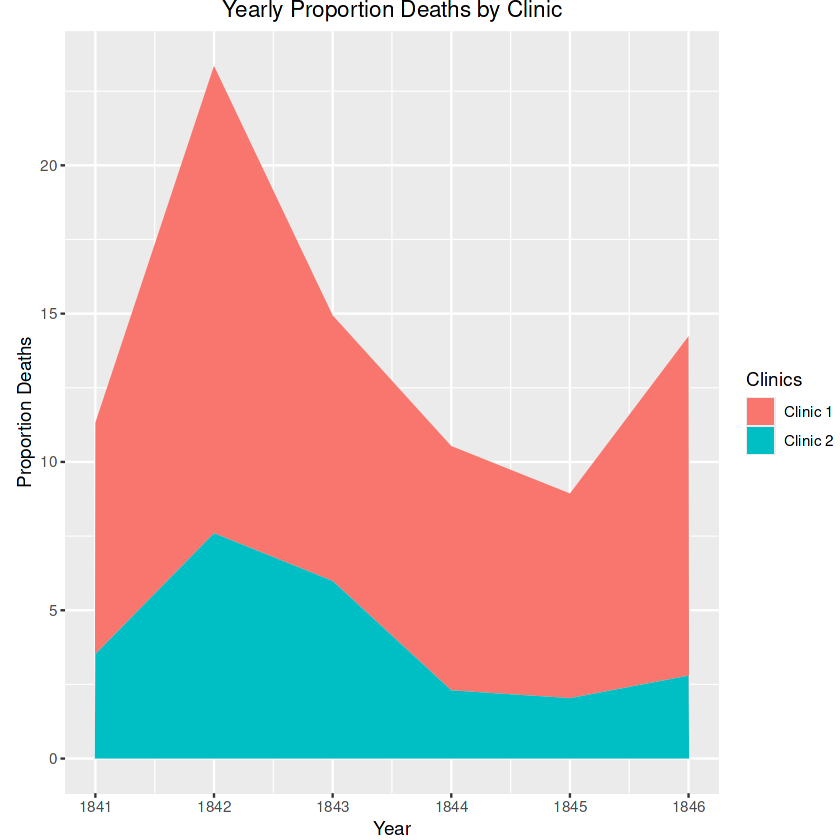

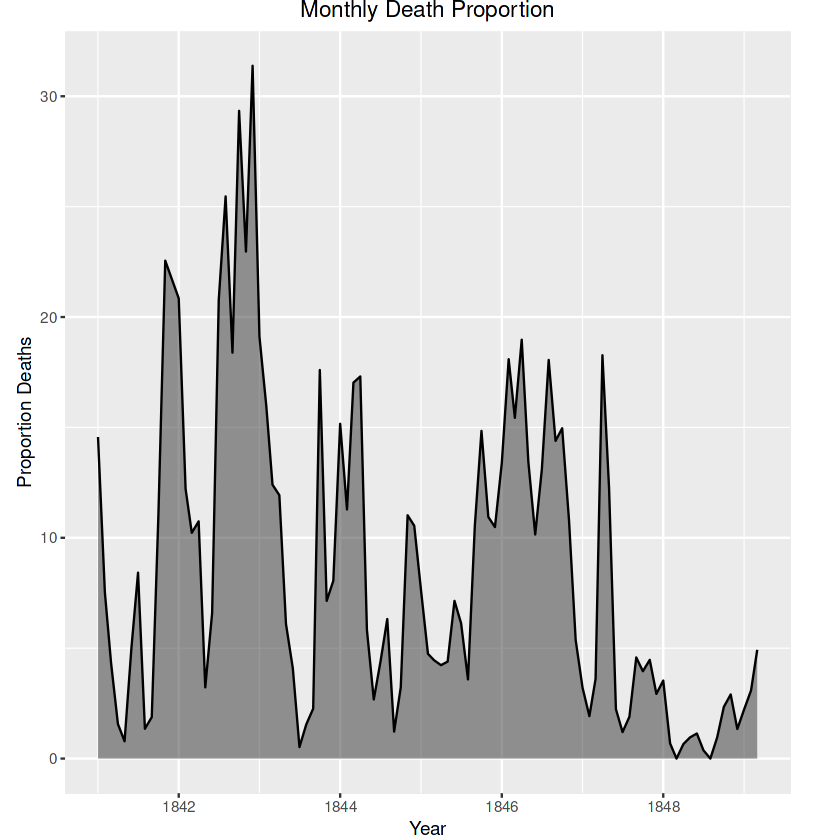

In [9]:
# Time for plotting the data. I'll be using line graphs to illustrate the change in the number of deaths before and after handwashing became common place

ggplot(yearly_deaths, aes(x = year, y = proportion_deaths, fill = clinic)) +
    geom_area(position = "stack") +
    labs(x = "Year", y = "Proportion Deaths") +
    labs(title = "Yearly Proportion Deaths by Clinic") +
    theme(plot.title = element_text(hjust = 0.5),plot.margin = margin(l = 10)) +
    scale_fill_discrete(name = "Clinics", labels = c("Clinic 1", "Clinic 2"))
    

ggplot(monthly_deaths, aes(x = date, y = proportion_deaths)) +
  geom_area(stat = "identity", alpha = 0.5) +
  geom_line() +
  labs(x = "Year", y = "Proportion Deaths") +
  labs(title = "Monthly Death Proportion") +
  theme(plot.title = element_text(hjust = 0.5), plot.margin = margin(l = 10, r=30))

Viola. We've got a baseline idea of how many deaths occurred annually. 

Now I'd like to add a threshold indicating the start of Semmelweis's discovery of handwashing, which will add context to the plots. 

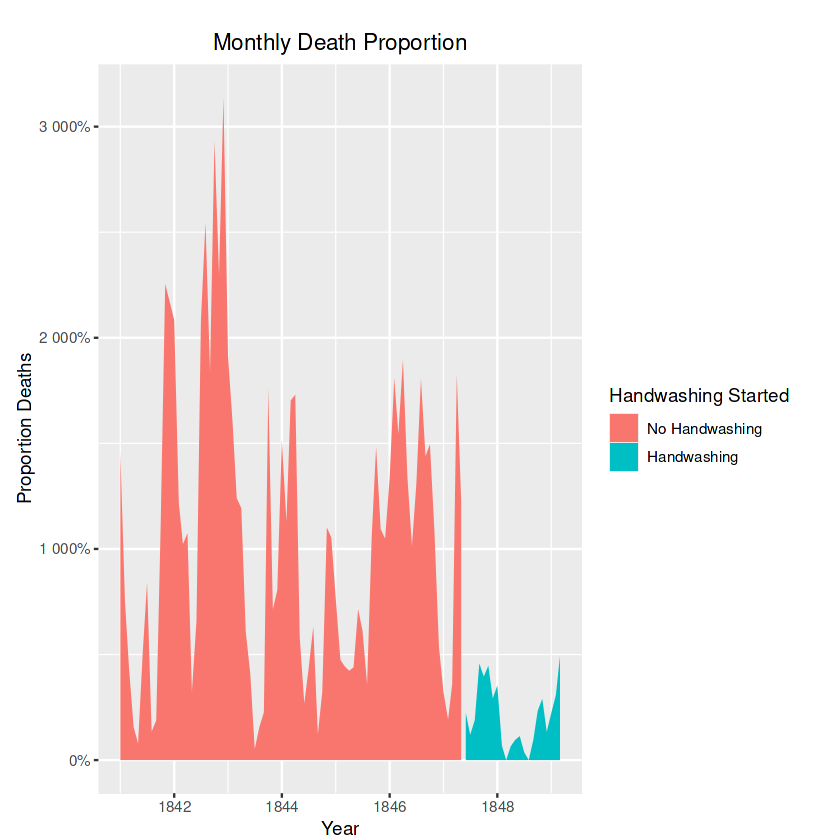

In [10]:
# Visualization of statistical differences before and after handwashing started.

ggplot(monthly_deaths, aes(x = date, y = proportion_deaths)) +
  geom_ribbon(aes(ymin = 0, ymax = proportion_deaths, fill = handwashing_started)) +
  scale_fill_discrete(name = "Handwashing Started", labels = c("No Handwashing", "Handwashing")) +
  scale_y_continuous(labels = scales::percent) + 
  labs(x = "Year", y = "Proportion Deaths", color = "Handwashing Began") +
  labs(title = "Monthly Death Proportion") +
  theme(plot.title = element_text(hjust = 0.5), plot.margin = margin(l = 10, r=30, t = 20))

There is a noticeable difference in the proportion of deaths to births following Semmelweis's discovery. It revolutionalized the medical industry functioned!

Lastly, I'm going to try to find thde mean proportion of deaths before and after handwashing using the monthly_deaths df. I'll do this by creating new variables 

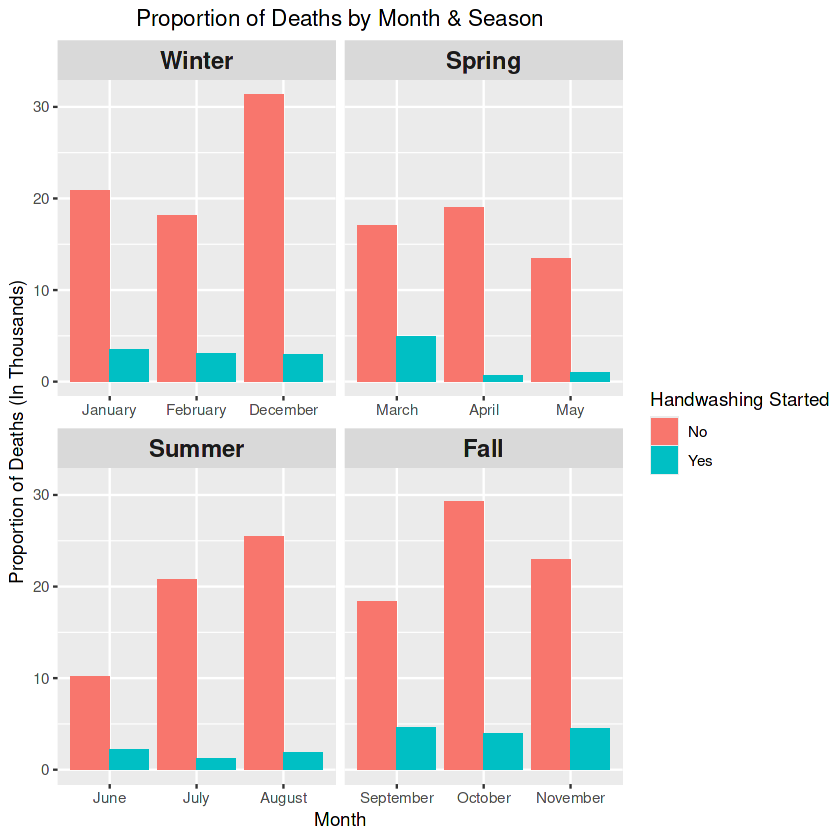

In [11]:
ggplot(monthly_deaths, aes(x = month, y = proportion_deaths, fill = handwashing_started)) +
    geom_bar(stat = "identity", position = "dodge") +
    facet_wrap(~ season, scales = "free_x") +
    labs(title = "Proportion of Deaths by Month & Season",
            x = "Month", 
            y = "Proportion of Deaths (In Thousands)", 
            fill =  "Handwashing Started") +
    scale_fill_discrete(labels = c("No", "Yes")) +
    theme(plot.title = element_text(hjust = 0.5),
         strip.text = element_text(size = 14, face = "bold"))

# Closing Notes

In this analysis, the data shows that the implementation of handwashing had a significant impact on reducing the proportion of deaths in European medical clinics during the late 1800s. Although the introduction of handwashing by Dr. Semmelweis markedly lowered the birth-to-death ratio, the analysis indicates that seasonal fluctuations still led to notable spikes in deaths, particularly between September and March. 

These spikes may be attributed to a combination of factors, such as inadequate sanitary infrastructure, prevailing cultural beliefs and norms surrounding medicine, and the limited medical knowledge of the time. Additionally, colder temperatures during these months, likely influenced by the lingering effects of the [Little Ice Age](https://en.wikipedia.org/wiki/Little_Ice_Age), may have exacerbated conditions, leading to higher mortality rates. The colder climate during this period, combined with insufficient medical and civic responses to seasonal health challenges, likely played a role in the increased deaths observed during the winter months.

While further research would be necessary to fully validate these hypotheses, the data clearly demonstrates that handwashing revolutionized medical practices and drastically improved patient outcomes. The findings emphasize how a simple, yet powerful intervention reshaped the medical industry and highlights the critical role of hygiene in healthcare, laying the groundwork for modern infection control practices.